#***MULTIPLE LINEAR REGRESSION ASSIGNMENT***

In [43]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

* Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.

In [2]:
# Load dataset
df = pd.read_csv("ToyotaCorolla - MLR.csv")
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
# Dataset overview
print("Shape:", df.shape)

Shape: (1436, 11)


In [4]:
print("Data types:", df.dtypes)

Data types: Price         int64
Age_08_04     int64
KM            int64
Fuel_Type    object
HP            int64
Automatic     int64
cc            int64
Doors         int64
Cylinders     int64
Gears         int64
Weight        int64
dtype: object


In [5]:
# Summary statistics
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [6]:
# Missing values
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


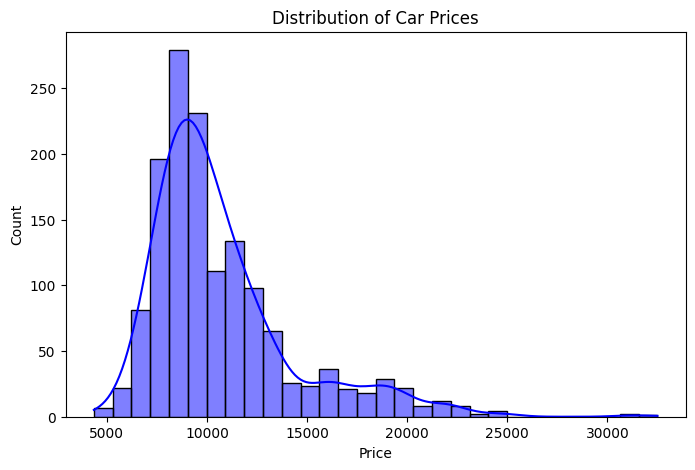

In [48]:
# Distribution of target variable (Price)
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True, bins=30, color="blue")
plt.title("Distribution of Car Prices")
plt.show()

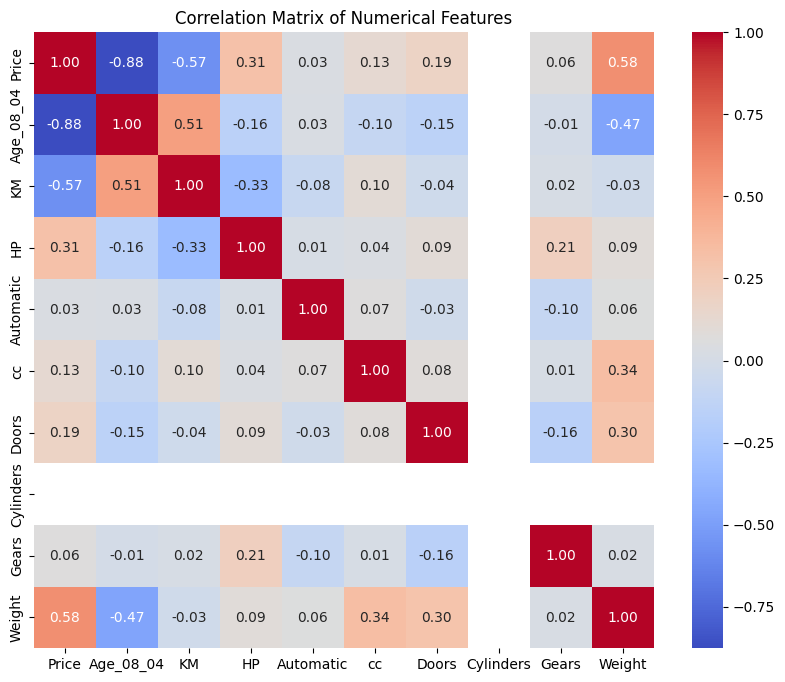

In [8]:
# correlation matrix for only numerical columns
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show() #

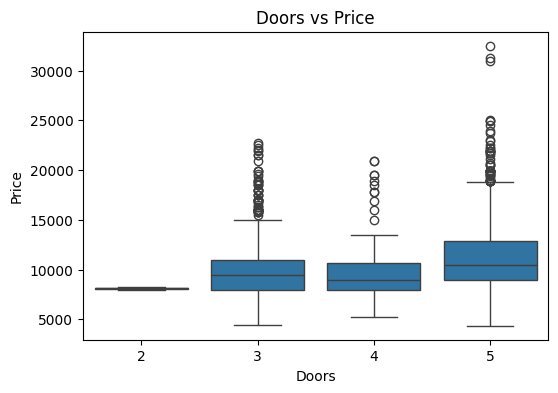

In [50]:
# Boxplot for categorical variable (Doors) vs Price
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Doors"], y=df["Price"])
plt.title("Doors vs Price")
plt.show()

* Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [54]:
features = ["Age", "KM", "HP", "Doors", "Weight"]
X = df.drop('Price', axis=1)
Y = df['Price']

# Split the data into 80% training and 20% testing
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=40
)

print(X_train.shape)
print(X_test.shape)
print(Y_test.shape)
print(Y_train.shape)

(1148, 11)
(288, 11)
(288,)
(1148,)


* Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

In [35]:
### Model 1: Basic Multiple Linear Regression
model1= LinearRegression()
model1.fit(X_train, Y_train)
y_pred1 = model1.predict(X_test)

In [37]:
print("\nModel 1 Coefficients:")
for feature, coef in zip(X.columns, model1.coef_):
    print(f"{feature}: {coef:.4f}")

print("Intercept:", model1.intercept_)
print("R2 Score:", r2_score(Y_test, y_pred1))
print("MSE:", mean_squared_error(Y_test, y_pred1))


Model 1 Coefficients:
Age_08_04: -129.0228
KM: -0.0166
HP: 23.6498
Automatic: 382.3611
cc: -0.0113
Doors: -16.2760
Cylinders: 0.0000
Gears: 602.0517
Weight: 17.7465
Fuel_Type_Diesel: 993.5738
Fuel_Type_Petrol: 1461.4528
Intercept: -6703.047165152459
R2 Score: 0.873207357284197
MSE: 1768877.174311733


In [33]:
# Model 2: Standardized Regression (with scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model2 = LinearRegression()
model2.fit(X_train_scaled, Y_train)

y_pred2 = model2.predict(X_test_scaled)

In [34]:
print("\nModel 2 Coefficients (Standardized):")
for feature, coef in zip(X.columns, model2.coef_):
    print(f"{feature}: {coef:.4f}")

print("Intercept:", model2.intercept_)
print("R2 Score:", r2_score(Y_test, y_pred2))
print("MSE:", mean_squared_error(Y_test, y_pred2))


Model 2 Coefficients (Standardized):
Age_08_04: -2400.1694
KM: -617.2646
HP: 347.6453
Automatic: 89.0056
cc: -5.2507
Doors: -15.4786
Cylinders: -0.0000
Gears: 111.1209
Weight: 923.4163
Fuel_Type_Diesel: 301.7296
Fuel_Type_Petrol: 461.5565
Intercept: 10762.134146341463
R2 Score: 0.8732073572841972
MSE: 1768877.1743117305


In [42]:
# Model 3: Polynomial Regression (degree=2)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model3 = LinearRegression()
model3.fit(X_train_poly, Y_train)

y_pred3 = model3.predict(X_test_poly)

print("\nModel 3 (Polynomial Regression) R2 Score:", r2_score(Y_test, y_pred3))
print("MSE:", mean_squared_error(Y_test, y_pred3))



Model 3 (Polynomial Regression) R2 Score: 0.9230338920496802
MSE: 1073749.932431726


* Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [46]:
# Evaluation metrics
print("\nModel Performance on Test Data:")

#r2_score
r2 = r2_score(Y_test, y_pred1)
print(f"\nR Square Score: {r2:.4f}")

#Mean Squared Error (MSE)
mse = mean_squared_error(Y_test, y_pred1)
print(f"Mean Squared Error (MSE): {mse:.2f}")

#Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

#Mean Absolute Error (MAE):
mae = mean_absolute_error(Y_test, y_pred1)
print(f"Mean Absolute Error (MAE): {mae:.2f}")


Model Performance on Test Data:

R Square Score: 0.8732
Mean Squared Error (MSE): 1768877.17
Root Mean Squared Error (RMSE): 1329.99
Mean Absolute Error (MAE): 959.96


* Apply Lasso and Ridge methods on the model.

In [55]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, Y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

print("\nRidge Regression Coefficients:")
for feature, coef in zip(features, ridge.coef_):
    print(f"{feature}: {coef:.4f}")

print("Intercept:", ridge.intercept_)
print("R2 Score:", r2_score(Y_test, y_pred_ridge))
print("MSE:", mean_squared_error(Y_test, y_pred_ridge))


Ridge Regression Coefficients:
Age: -2397.1906
KM: -618.9399
HP: 347.3499
Doors: 88.7434
Weight: -4.9502
Intercept: 10762.134146341463
R2 Score: 0.8733104951555054
MSE: 1767438.3035503323


In [57]:
# Lasso Regression
lasso = Lasso(alpha=0.1)   # smaller alpha for Lasso
lasso.fit(X_train_scaled, Y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

print("\nLasso Regression Coefficients:")
for feature, coef in zip(features, lasso.coef_):
    print(f"{feature}: {coef:.4f}")

print("Intercept:", lasso.intercept_)
print("R2 Score:", r2_score(Y_test, y_pred_lasso))
print("MSE:", mean_squared_error(Y_test, y_pred_lasso))



Lasso Regression Coefficients:
Age: -2400.0826
KM: -617.3189
HP: 347.3115
Doors: 88.8524
Weight: -5.0362
Intercept: 10762.134146341463
R2 Score: 0.8732192901640065
MSE: 1768710.699362819
